In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys
import h5py
sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')

from scipy.stats import norm
from tkinter import *
import scipy
from scipy import signal

import platform
from glob import glob
from scipy.spatial import distance
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
import IO_func as IOF
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
import LL_funcs as LLf
import freq_funcs as ff
#
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from tqdm.notebook import trange, tqdm
import significance_funcs as sig_func
import load_summary as ls
dist_groups = np.array([[0, 30], [30, 60], [60, 120]])

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
dist_labels = ['local (<30 mm)', 'short (<60mm)', 'long']
Fs = 500
dur = np.zeros((1, 2), dtype=np.int32)
t0 = 1
dur[0, 0] = -t0
dur[0, 1] = 3

folder = 'InputOutput'
# dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax = np.arange(dur[0, 0], dur[0, 1], (1 / Fs))
color_elab = np.zeros((3, 3))
color_elab[0, :] = np.array([31, 78, 121]) / 255
color_elab[1, :] = np.array([189, 215, 238]) / 255
color_elab[2, :] = np.array([0.256, 0.574, 0.431])
cwd = os.getcwd()

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib 
import matplotlib.cm as cm
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [3]:
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab

In [4]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [5]:
Fs             = 500
dur            = np.zeros((1,2), dtype=np.int32)
t0 = 1
dur[0,0] =  -t0
dur[0,1] =  3

#dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax           = np.arange(dur[0,0],dur[0,1],(1/Fs))
color_elab      = np.zeros((4,3))
color_elab[0,:] = np.array([31, 78, 121])/255
color_elab[1,:] = np.array([189, 215, 238])/255
color_elab[2,:] = np.array([0.256, 0.574, 0.431])


In [6]:
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab

##
subjs = ["EL004","EL005","EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]
stop

NameError: name 'stop' is not defined

## GENERAL

In [8]:

df_auc_all =  ls.get_AUC(subjs, sub_path, ss ='general')
df_auc_sig = df_auc_all.loc[(df_auc_all.AUC_p<0.01)&(df_auc_all.MAX_p<0.01)&(df_auc_all.rho_p<0.01)].reset_index(drop=True)

In [43]:
def adding_region(data_con, pair=1, area='Region'):
    # area == 'Region' or 'Area'
    CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
    atlas = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')
    if pair:
        for subregion in np.unique(data_con[['StimA', 'ChanA']]):
            region = atlas.loc[atlas.Abbreviation == subregion, area].values
            if len(region) > 0:
                data_con.loc[data_con.StimA == subregion, 'StimR'] = region[0]
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
            else:
                region = atlas.loc[atlas['Extra-Modifier'] == subregion, area].values
                if len(region) > 0:
                    data_con.loc[data_con.StimA == subregion, 'StimR'] = region[0]
                    data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
                else:
                    data_con.loc[data_con.StimA == subregion, 'StimR'] = 'U'
                    data_con.loc[data_con.ChanA == subregion, 'ChanR'] = 'U'
    else:
        for subregion in np.unique(data_con[['ChanA']]):
            region = atlas.loc[atlas.Abbreviation == subregion, area].values
            if len(region) > 0:
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = region[0]
            else:
                data_con.loc[data_con.ChanA == subregion, 'ChanR'] = 'U'
    return data_con

In [44]:
df_auc_all = adding_region(df_auc_all, pair=1, area='Region')

In [45]:
df_auc_all

,Stim,Chan,AUC,MAX,rho,AUC_p,MAX_p,rho_p,d,ChanA,StimA,H,StimR,ChanR,StimSR,ChanSR,peak_latency,onset,Subj
0,5,0,0.700470,0.941572,0.918343,0.0,0.0,0.0,17.50,CircIS_sup,PostCS_inf,0.0,Central,Insula,U,CircIS,0.020,0.000,EL004
1,5,1,0.757992,0.981084,0.886024,0.0,0.0,0.0,14.00,PostCS_inf,PostCS_inf,0.0,Central,Central,U,U,0.018,0.000,EL004
2,5,2,0.762734,0.965919,0.869992,0.0,0.0,0.0,10.50,PostCS_inf,PostCS_inf,0.0,Central,Central,U,U,0.018,0.000,EL004
3,5,3,0.706443,0.949637,0.927199,0.0,0.0,0.0,7.00,PostCS_inf,PostCS_inf,0.0,Central,Central,U,U,0.016,0.000,EL004
4,5,7,0.842801,0.989609,0.798156,0.0,0.0,0.0,0.00,PostCS_inf,PostCS_inf,0.0,Central,Central,U,U,0.014,0.000,EL004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4831,53,85,0.561932,0.939165,0.958150,0.0,0.0,0.0,62.03,MFS,HIPP,0.0,Hippocampus,Dorsofrontal,Hipp,MFS,0.072,0.024,EL028
4832,53,86,0.600500,0.981864,0.937749,0.0,0.0,0.0,65.45,MFS,HIPP,0.0,Hippocampus,Dorsofrontal,Hipp,MFS,0.204,0.140,EL028
4833,53,87,0.631106,0.954486,0.909173,0.0,0.0,0.0,68.88,MFG,HIPP,0.0,Hippocampus,Dorsofrontal,Hipp,MFG,0.072,0.000,EL028
4834,53,88,0.556193,0.947940,0.979313,0.0,0.0,0.0,72.31,MFG,HIPP,0.0,Hippocampus,Dorsofrontal,Hipp,MFG,0.110,0.040,EL028


In [9]:
df_auc_sig['Group'] = 'local'
df_auc_sig.loc[(df_auc_sig.d>20)&(df_auc_sig.onset>=0.02), 'Group']  = 'Indirect'
df_auc_sig.loc[(df_auc_sig.d>20)&(df_auc_sig.onset<0.02), 'Group']  = 'Direct'

In [10]:
delay_cut = 0.02# 0.05, 0.02
delay_sel = 'onset' # 'peak_latency' , 'onset'
delay_label = 'CCEP onset [s]' # 'CCEP onset [s]', 'peak latency [s]'
df = df_auc_sig[~np.isnan(df_auc_sig[delay_sel])].reset_index(drop=True)
df['Group'] = 'local'
df.loc[(df.d>20)&(df.onset>=delay_cut), 'Group']  = 'Indirect'
df.loc[(df.d>20)&(df.onset<delay_cut), 'Group']  = 'Direct'

In [11]:
group_order1 = ['local', 'Direct','Indirect',  ]

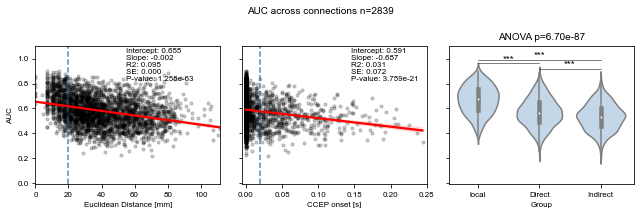

In [33]:
# Assuming df is your DataFrame
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=True)
plt.suptitle(f'AUC across connections n={len(df)}')

# Continuous variables plots
for i, (ax, (x_var, title, line_at),yt) in enumerate(zip(axes.flat, [
    ('d', 'Euclidean Distance [mm]', 20),
    (delay_sel, delay_label, delay_cut)], [55, 0.145])):
    sns.regplot(x=x_var, y='AUC', data=df, ax=ax, line_kws={'color': "r"}, scatter_kws={'s': 10, 'color': 'black', 'alpha': 0.2})
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[x_var],df['AUC'])
    text_str = f'Intercept: {intercept:.3f}\nSlope: {slope:.3f}\nR2: {r_value**2:.3f}\nSE: {std_err:.3f}\nP-value: {p_value:.3e}'
    ax.text(yt, 0.82, text_str, fontsize = 8)


    #r, p = scipy.stats.pearsonr(df[x_var], df['AUC'])
    #ax.set_title(f'R²={np.round(r**2, 3)}, p={p:.2e}')
    if line_at is not None:
        ax.axvline(line_at, ls='--', alpha=0.7, color=color_elab[0])
    ax.set_xlabel(title)
axes[0].set_ylabel('AUC')
axes[0].set_ylim([-0.01, 1.1])
axes[1].set_ylabel('')

axes[1].set_xlim([-0.005, 0.25])

# Group comparison
ax_group = axes[2]
sns.violinplot(x='Group', y='AUC', data=df, ax=ax_group, order = group_order1, color= color_elab[1])
ax_group.set_xlabel('Group')

# ANOVA
model = ols('AUC ~ C(Group)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Check if the ANOVA is significant
ax_group.set_title('ANOVA p={:.2e}'.format(anova_table['PR(>F)'][0]))
if anova_table['PR(>F)'][0] < 0.05:
    
    # Post-hoc test if ANOVA is significant
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    posthoc = pairwise_tukeyhsd(df['AUC'], df['Group'], alpha=0.05)
    
    # Extract group names and means for positioning
    group_means = df.groupby('Group')['AUC'].mean().sort_values()
    # group_order = group_means.index
    
    # Annotations based on Tukey's test results
    comparisons = posthoc.summary().data[1:]  # Skip the header row
    for ix_comp, comparison in enumerate(comparisons):
        group1, group2, p_value = comparison[0], comparison[1], comparison[3]
        if p_value < 0.001:
            sig = '***'
        elif p_value < 0.01:
            sig = '**'
        elif p_value < 0.05:
            sig = '*'
        else:
            sig = 'n.s.'
        
        # sig =f'{p_value:0.2e}'
        # Find positions for text annotation
        y_pos = df.loc[np.isin(df.Group,[group1,group2]),'AUC'].max() + (ix_comp+1)*0.03  # Adjust 0.05 or as needed for your data
        x1 = group_order1.index(group1) # group_order.get_loc(group1)
        x2 = group_order1.index(group2) #group_order.get_loc(group2)
        # Draw a line between the groups
        ax_group.plot([x1, x2], [y_pos, y_pos], color='black', lw=0.5)
        
        # Add significance symbol
        ax_group.text((x1+x2)*0.5, y_pos, sig, ha='center', va='bottom', color='black')
else:
    ax_group.set_title('No significant difference')

axes[2].set_ylabel('')
plt.tight_layout()
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\IO\General\\AUC_d_delay_group.svg'   
plt.savefig(file)

In [ ]:
for g in group_order1:
    print(g)
    md = np.median(df.loc[df.Group==g, 'AUC'])
    iq1 = np.quantile(df.loc[df.Group==g, 'AUC'],0.25)
    iq3 = np.quantile(df.loc[df.Group==g, 'AUC'],0.75)
    print(np.round(md,2), np.round(iq1,2), np.round(iq3,2))

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 4
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 2
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 63, but rank is 55
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 1
  'ran

                      sum_sq      df          F        PR(>F)
C(StimR)            4.053652     7.0  54.342706  9.766026e-44
C(ChanR)            1.007871     9.0  10.508853  2.869165e-05
C(StimR):C(ChanR)   3.935099    63.0   5.861489  3.151173e-36
Residual           23.411929  2197.0        NaN           NaN
                         sum_sq     df             F    PR(>F)
C(StimR)           3.507549e-12    6.0  6.085466e-11  0.999994
C(ChanR)           2.615722e-02    8.0  3.403635e-01  0.560114
C(StimR):C(ChanR)  1.245873e+00   48.0  2.701929e+00  0.000074
Residual           2.555291e+00  266.0           NaN       NaN


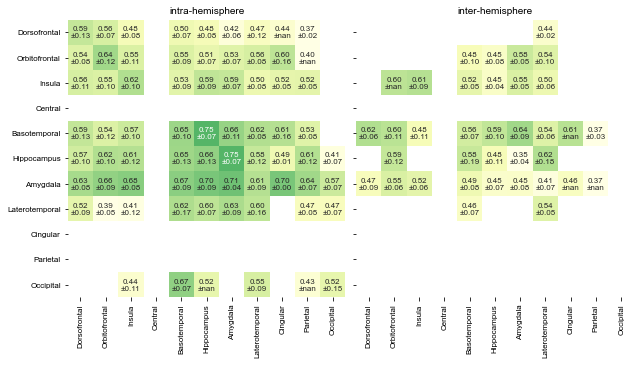

In [46]:
# data preparation
metric = 'AUC'

cal = 'mean'

    # metric = 'Sig'
metric_label = 'AUC'
cmap_metric = 'RdGy_r'
vmin = 0.4
cmap_metric = 'YlGn'

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
for h in range(2):
    ax = axes[h]
    data_Con_prob = df[['Subj', 'StimR', 'ChanR', 'AUC','d', 'H']].reset_index(drop=True)
    data_Con_prob = data_Con_prob[ (data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
    data_Con_prob = data_Con_prob[~np.isnan(data_Con_prob[metric])]
    grouped_data = data_Con_prob.groupby(['StimR', 'ChanR'])[metric].agg([cal, 'std'])

    # 2. Create a Data Matrix
    data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
    for (stim, chan), values in grouped_data.iterrows():
        if stim in regions_all and chan in regions_all:
            data_matrix.at[stim, chan] = f"{values[cal]:.2f}\n±{values['std']:.2f}"

    # Reorder data matrix and annotation matrix
    reordered_data = grouped_data[cal].unstack().reindex(index=regions_all, columns=regions_all)
    annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)
    
    sns.heatmap(reordered_data, ax=ax, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap_metric, cbar=False, vmin =vmin, vmax=1)
    ax.set_ylabel('')
    ax.set_xlabel('')
    if h:
        ax.set_title('inter-hemisphere')
    else:
        ax.set_title('intra-hemisphere')
    # Ensuring the heatmap is square
    ax.set_aspect('equal', 'box')
    model = ols('AUC ~ C(StimR) + C(ChanR) + C(StimR):C(ChanR)', data=data_Con_prob).fit() 
    tw_anova = sm.stats.anova_lm(model, typ=2)
    print(tw_anova)
plt.tight_layout()
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\IO\General\\AUC_regions_both.svg'   
plt.savefig(file)
plt.show()

In [ ]:
model = ols('AUC ~ C(StimR) + C(ChanR) + C(StimR):C(ChanR)', data=data_Con_prob).fit() 
    tw_anova = sm.stats.anova_lm(model, typ=2)
    print(tw_anova)

In [52]:
len(data_Con_prob)

2570

In [51]:
data_Con_prob = df[['Subj', 'StimR', 'ChanR', 'AUC','d', 'H']].reset_index(drop=True)
    
data_Con_prob = data_Con_prob[(np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
    

In [55]:
data_con_file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\IO\\AUC_anova.tex' 
metrics = ['AUC']
metric_labels = ['gain-AUC']
# Assuming 'data_epi' is your DataFrame, and it's already been defined
# Also assuming 'metrics', 'metric_labels', and 'data_con_file' are defined

with open(data_con_file, 'w') as file:
    for h, label in zip([0,1],['intra-hemisphere', 'inter-hemisphere']):
        
        data_Con_prob = df[['Subj', 'StimR', 'ChanR', 'AUC','d', 'H']].reset_index(drop=True)
    
        data_Con_prob = data_Con_prob[(data_Con_prob.H == h) &(np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
        print(len(data_Con_prob))
        # Fit the model for each metric with an interaction term between ChanR and Epilepsy
        model = ols(f'{metric} ~ C(StimR)*C(ChanR) ', data=data_Con_prob).fit()


        # Perform ANOVA
        anova_results = sm.stats.anova_lm(model, typ=2)

        # Convert the ANOVA table to LaTeX
        anova_latex = anova_results.to_latex(index=True)

        # Write a section title for each metric to the LaTeX file for clarity
        file.write(f"\n\\section*{{{label}}}\n")
        file.write(anova_latex)
        file.write("\n")  # Add some space after each table for better readability

2268
302


C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 4
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 2
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 63, but rank is 55
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 1
  'ran

In [ ]:
# Importing libraries 
import statsmodels.api as sm 
from statsmodels.formula.api import ols 

# Performing two-way ANOVA 
model = ols('AUC ~ C(StimR) + C(ChanR) + C(StimR):C(ChanR)', data=data_Con_prob).fit() 
tw_anova = sm.stats.anova_lm(model, typ=2) 


## Sleep modulation

In [56]:
# Importing libraries 
import statsmodels.api as sm 
from statsmodels.formula.api import ols 
import statsmodels

In [57]:
df_auc_all =  ls.get_AUC(subjs, sub_path, ss ='ss')
df_auc_all = df_auc_all.merge(df[['Subj', 'Stim','Chan', 'onset', 'Group']], on= ['Subj', 'Stim','Chan']).reset_index(drop=True)


In [58]:
ss ='NREM'
df_sleep = df_auc_all[~np.isnan(df_auc_all.cohens_d)&~np.isnan(df_auc_all.onset)&(df_auc_all.d >7)&(df_auc_all.SleepState ==ss)].reset_index(drop=True)
df_sleep['cd_abs'] = abs(df_sleep['cohens_d'])

In [63]:
df_sleep['p_value'] = 0
p_values = df_sleep['p_value_T'].values
p_sig, p_corr = statsmodels.stats.multitest.fdrcorrection(p_values)
df_sleep['p_value'] = np.array(p_sig*1)
len(df_sleep[df_sleep.p_value==1])/len(df_sleep)

0.8978043912175648

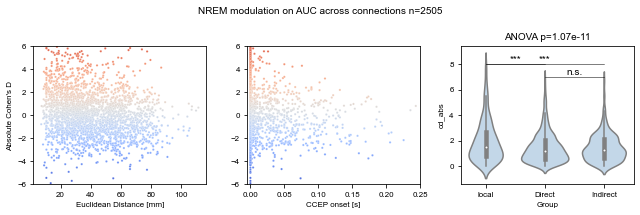

In [61]:
# Assuming df is your DataFrame
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
plt.suptitle(f'{ss} modulation on AUC across connections n={len(df_sleep)}')
y_metric = 'cohens_d'
# Continuous variables plots
for i, (ax, (x_var, title, line_at)) in enumerate(zip(axes.flat, [
    ('d', 'Euclidean Distance [mm]', 20),
    (delay_sel, delay_label, delay_cut)])):
    
    sns.scatterplot(x=x_var, y=y_metric, hue ='cohens_d', data=df_sleep, ax=ax, s=5, alpha=1, palette="coolwarm", legend =False)
    # sns.regplot(x=x_var, y=y_metric, data=df_sleep, ax=ax, line_kws={'color': "r"}, scatter_kws={'s': 10, 'color': 'black', 'alpha': 0.2})
    # r, p = scipy.stats.pearsonr(df_sleep[x_var], df_sleep[y_metric])
    #ax.set_title(f'R²={np.round(r**2, 3)}, p={p:.2e}')
    #if line_at is not None:
    #    ax.axvline(line_at, ls='--', alpha=0.7, color=color_elab[0])
    ax.set_xlabel(title)
axes[0].set_ylabel("Cohen's D")
axes[0].set_ylim([-6,6])
axes[1].set_ylabel('')
axes[1].set_ylim([-6,6])
axes[1].set_xlim([-0.005, 0.25])

# Group comparison
y_metric = 'cd_abs'
ax_group = axes[2]
sns.violinplot(x='Group', y=y_metric, data=df_sleep, ax=ax_group, order = group_order1, color= color_elab[1])
ax_group.set_xlabel('Group')

# ANOVA
model = ols(y_metric+' ~ C(Group)', data=df_sleep).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Check if the ANOVA is significant
ax_group.set_title('ANOVA p={:.2e}'.format(anova_table['PR(>F)'][0]))
if anova_table['PR(>F)'][0] < 0.05:
    
    # Post-hoc test if ANOVA is significant
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    posthoc = pairwise_tukeyhsd(df_sleep[y_metric], df_sleep['Group'], alpha=0.05)
    
    # Extract group names and means for positioning
    group_means = df_sleep.groupby('Group')[y_metric].mean().sort_values()
    # group_order = group_means.index
    
    # Annotations based on Tukey's test results
    comparisons = posthoc.summary().data[1:]  # Skip the header row
    for ix_comp, comparison in enumerate(comparisons):
        group1, group2, p_value = comparison[0], comparison[1], comparison[3]
        if p_value < 0.001:
            sig = '***'
        elif p_value < 0.01:
            sig = '**'
        elif p_value < 0.05:
            sig = '*'
        else:
            sig = 'n.s.'
        # Find positions for text annotation
        y_pos = df_sleep.loc[np.isin(df_sleep.Group,[group1,group2]),y_metric].max() + (ix_comp+1)*0.03  # Adjust 0.05 or as needed for your data
        x1 = group_order1.index(group1) # group_order.get_loc(group1)
        x2 = group_order1.index(group2) #group_order.get_loc(group2)
        # Draw a line between the groups
        ax_group.plot([x1, x2], [y_pos, y_pos], color='black', lw=0.5)
        
        # Add significance symbol
        ax_group.text((x1+x2)*0.5, y_pos, sig, ha='center', va='bottom', color='black')
else:
    ax_group.set_title('No significant difference')

axes[0].set_ylabel("Absolute Cohen's D")
plt.tight_layout()
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\IO\Sleep\\'+ss+'_d_delay_group.svg'   
plt.savefig(file)

In [ ]:
for g in group_order1:
    print(g)
    md = np.median(df_sleep.loc[df_sleep.Group==g, 'cd_abs'])
    iq1 = np.quantile(df_sleep.loc[df_sleep.Group==g, 'cd_abs'],0.25)
    iq3 = np.quantile(df_sleep.loc[df_sleep.Group==g, 'cd_abs'],0.75)
    print(str(np.round(md,2)) +' ['+str(np.round(iq1,2))+', '+str(np.round(iq3,2))+']')

In [ ]:
for SR in ['Hippocampus', 'Amygdala']:
    val = data_Con_prob.loc[(data_Con_prob.StimR==SR)&(data_Con_prob.ChanR =='Orbitofrontal'), 'cohens_d'].values
    md = np.median(val)
    iq1 = np.quantile(val,0.25)
    iq3 = np.quantile(val,0.75)
    print(str(np.round(md,2)) +' ['+str(np.round(iq1,2))+', '+str(np.round(iq3,2))+']')

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 79, but rank is 70
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 62, but rank is 35
  'rank is %d' % (J, J_), ValueWarning)


                        sum_sq      df         F        PR(>F)
C(StimR):C(ChanR)  2256.807636    79.0  7.963137  5.761191e-66
Residual           7031.360446  1960.0       NaN           NaN
                       sum_sq     df         F        PR(>F)
C(StimR):C(ChanR)  500.397536   62.0  8.360372  1.332126e-26
Residual           256.790842  266.0       NaN           NaN


C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 79, but rank is 70
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 62, but rank is 35
  'rank is %d' % (J, J_), ValueWarning)


                        sum_sq      df         F        PR(>F)
C(StimR):C(ChanR)  1477.952411    79.0  6.147404  3.441802e-46
Residual           5219.221510  1715.0       NaN           NaN
                       sum_sq     df         F        PR(>F)
C(StimR):C(ChanR)  579.304365   62.0  8.500851  1.423019e-26
Residual           278.082211  253.0       NaN           NaN


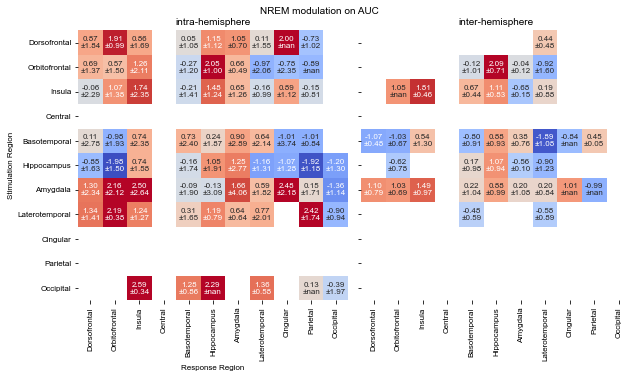

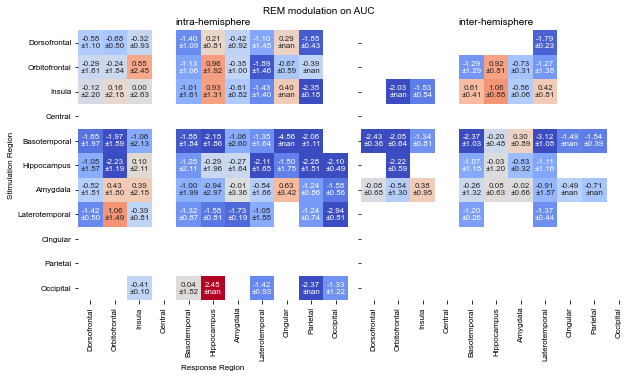

In [67]:

metric = 'cohens_d'

cal = 'mean'

    # metric = 'Sig'
metric_label = 'cohens_d'
cmap_metric = 'RdGy_r'

cmap_metric = 'coolwarm'



for ss in ['NREM', 'REM']:
    fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
    plt.suptitle(ss+ ' modulation on AUC')
    for h in range(2):
        ax = axes[h]
        data_sel =df_auc_all[df_auc_all.SleepState==ss].reset_index(drop=True)
        data_Con_prob = data_sel[['Subj', 'StimR', 'ChanR', 'AUC_mean','cohens_d','d', 'H']].reset_index(drop=True)
        data_Con_prob = data_Con_prob[ (data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
        data_Con_prob = data_Con_prob[~np.isnan(data_Con_prob[metric])]
        grouped_data = data_Con_prob.groupby(['StimR', 'ChanR'])[metric].agg([cal, 'std'])

        # 2. Create a Data Matrix
        data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
        for (stim, chan), values in grouped_data.iterrows():
            if stim in regions_all and chan in regions_all:
                data_matrix.at[stim, chan] = f"{values[cal]:.2f}\n±{values['std']:.2f}"

        # Reorder data matrix and annotation matrix
        reordered_data = grouped_data[cal].unstack().reindex(index=regions_all, columns=regions_all)
        annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

        ax = sns.heatmap(reordered_data, ax=ax, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap_metric, cbar=False, vmin =-2, vmax=2)
        if h == 0:
            ax.set_ylabel('Stimulation Region')
            ax.set_xlabel('Response Region')
            ax.set_title('intra-hemisphere')
        else:
            ax.set_ylabel('')
            ax.set_xlabel('')
            ax.set_title('inter-hemisphere')
        # Ensuring the heatmap is square
        ax.set_aspect('equal', 'box')
        model = ols(metric+' ~ C(StimR):C(ChanR)', data=data_Con_prob).fit() 
        tw_anova = sm.stats.anova_lm(model, typ=2) 
        print(tw_anova)
    plt.tight_layout()
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\IO\Sleep\\'+ss+'_'+metric+'_regions_across.svg'
    # plt.savefig(file)

In [70]:
data_con_file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Sleep\\AUC_anova.tex' 
metrics = ['AUC']
metric_labels = ['gain-AUC']
# Assuming 'data_epi' is your DataFrame, and it's already been defined
# Also assuming 'metrics', 'metric_labels', and 'data_con_file' are defined

with open(data_con_file, 'w') as file:
    for ss_sel in ['NREM', 'REM']:
        data_sel =df_auc_all[df_auc_all.SleepState==ss_sel].reset_index(drop=True)
        for h, label in zip([0,1],['intra-hemisphere', 'inter-hemisphere']):

            
            data_Con_prob = data_sel[['Subj', 'StimR', 'ChanR', 'AUC_mean','cohens_d','d', 'H']].reset_index(drop=True)
            data_Con_prob = data_Con_prob[ (data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
            print(len(data_Con_prob))
            # Fit the model for each metric with an interaction term between ChanR and Epilepsy
            model = ols(f'{metric} ~ C(StimR)*C(ChanR) ', data=data_Con_prob).fit()


            # Perform ANOVA
            anova_results = sm.stats.anova_lm(model, typ=2)

            # Convert the ANOVA table to LaTeX
            anova_latex = anova_results.to_latex(index=True)
 
            # Write a section title for each metric to the LaTeX file for clarity
            #file.write(f"\n\\section*{{{label}}}\n")
            file.write(f"{ss_sel}: {label}\\ \n")
            file.write(anova_latex)
            file.write("\n")  # Add some space after each table for better readability

2151
302
1864
289


C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 2
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 63, but rank is 55
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 1
  'ran

## Sleep modulation in sub-network

In [41]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [78]:
regions_all

array(['Dorsofrontal', 'Orbitofrontal', 'Insula', 'Central',
       'Basotemporal', 'Hippocampus', 'Amygdala', 'Laterotemporal',
       'Cingular', 'Parietal', 'Occipital'], dtype=object)

In [79]:
regions_all = ['Dorsofrontal', 'Orbitofrontal', 'Insula', 'Central',
       'Basotemporal', 'Hippocampus', 'Amygdala', 'Laterotemporal', 'Occipital']

In [45]:
df_auc_nmf =  ls.get_AUC_NMF_sleep(subjs, sub_path)
df_auc_nmf['SN_ID'] = df_auc_nmf.groupby(['Subj', 'Stim', 'H']).ngroup()

In [46]:
data_plot = df_auc_nmf[np.isin(df_auc_nmf.SleepState, ['NREM', 'REM'])&np.isin(df_auc_nmf.ChanR, regions_all)].reset_index(drop=True)

In [88]:
df_auc_nmf_mean = df_auc_nmf.groupby(['SN_ID'], as_index=False)['k'].mean()

In [96]:
len(np.unique(df_auc_nmf['Subj']))

17

In [95]:
np.max(df_auc_nmf_mean.k)

7

In [93]:
np.quantile(df_auc_nmf_mean.k, 0.75)

5.0

In [85]:
len(np.unique(df_auc_nmf.SN_ID))

75

In [76]:
color_sleep = ['#808080', '#919FC7', '#ED936B']
label_sleep = ['Wake', 'NREM', 'REM']

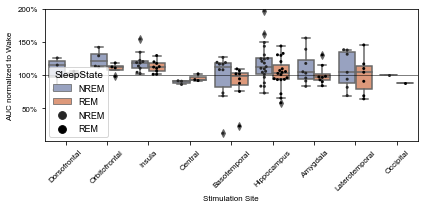

In [102]:
fig, ax = plt.subplots(figsize=(6, 3))

# Boxplot first to appear behind the swarmplot
sns.boxplot(x='ChanR', y='AUC_ratio', hue='SleepState', data=data_plot, dodge=True, order=regions_all, ax=ax, palette = color_sleep[1:])
sns.swarmplot(x='ChanR', y='AUC_ratio', hue='SleepState', data=data_plot, dodge=True, order=regions_all, ax=ax, color='k', s= 3)

ax.set_ylim([0, 2])
ax.set_yticks([0.5, 1, 1.5, 2])
ax.set_yticklabels(['50%', '100%', '150%', '200%'])
ax.set_ylabel('AUC normalized to Wake')
ax.set_xlabel('Stimulation Site')
ax.axhline(1, color = 'k', alpha = 0.5, linewidth = 1)
plt.xticks(rotation=45)  # Rotate x-axis tick labels if necessary
plt.tight_layout()
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\IO\Sleep\\AUC_normalkized_NMF.svg'   
plt.savefig(file)

In [58]:
data_limb = df_auc_nmf[np.isin(df_auc_nmf.SleepState, ['NREM', 'REM'])&np.isin(df_auc_nmf.ChanR, ['Hippocampus', 'Amygdala'])].reset_index(drop=True)

<AxesSubplot:xlabel='ChanR', ylabel='AUC_ratio'>

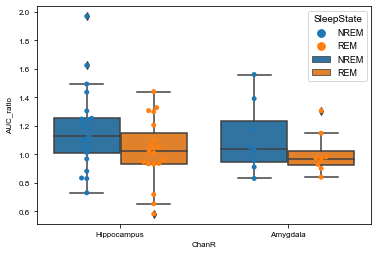

In [67]:
sns.swarmplot(x='ChanR', y= 'AUC_ratio', hue='SleepState', data = data_limb, dodge = True)
sns.boxplot(x='ChanR', y= 'AUC_ratio', hue='SleepState', data = data_limb, dodge = True)

<AxesSubplot:xlabel='ChanR', ylabel='AUC_ratio'>

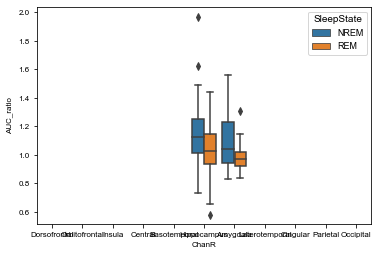

In [59]:
sns.boxplot(x='ChanR', y= 'AUC_ratio', hue='SleepState', data = data_plot, order = regions_all)

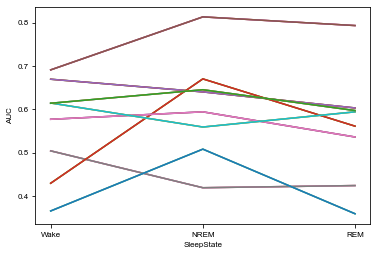

In [23]:
chanr_sel = 'Amygdala'
df_sel = df_auc_nmf[df_auc_nmf.ChanR == chanr_sel].reset_index(drop=True)
for sn in df_sel.SN_ID:
    dat_plot = df_sel[df_sel.SN_ID == sn].reset_index(drop=True)
    sns.lineplot(x= 'SleepState', y= 'AUC', data = dat_plot)